LABORATORIO 2:
HECHO POR: CAROLINA CHINCHILLA & WILLIAM POLLOCK (GRUPO 33)

In [2]:
#0: CARGA DE DATOS EN BASE AL LABORATORIO 1
#------------------------------------------
import pandas as pd

train = pd.read_csv("./data/Datos Lab 1.csv")
test = pd.read_csv("./data/Datos Test Lab 1.csv", sep=";")
dicc = pd.read_excel("./data/DiccPacientes.xlsx")

#para ver si funciona bien
display(dicc.head())
print(train.shape, test.shape)

import numpy as np

print("Duplicados:", train.duplicated().sum())
na = (train.isna().mean()*100).sort_values(ascending=False)
display(na.head(10))

display(train.describe(include="all"))

cat_cols = ["Sex", "Smoking Status", "Diabetes Status", "Physical Activity Level", "Family History of CVD", "Blood Pressure Category", "CVD Risk Level"]
for c in cat_cols:
    print("\n", c)
    display(train[c].astype(str).str.strip().str.upper().value_counts(dropna=False))

train2 = train.drop_duplicates().copy()
train2 = train2[train2["CVD Risk Score"].notna()].copy()

from sklearn.model_selection import train_test_split

X = train2.drop(columns=["CVD Risk Score", "CVD Risk Level"], errors="ignore")
y = train2["CVD Risk Score"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

drop_comun = ["Patient ID", "Date of Service", "Blood Pressure (mmHg)"]

X_temp = X.drop(columns=drop_comun, errors="ignore")
num_cols = X_temp.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_temp.select_dtypes(exclude=["number"]).columns.tolist()

print("Columnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso


(1639, 24) (194, 22)
Duplicados: 151


Diastolic BP                    5.186089
HDL (mg/dL)                     5.003051
Waist-to-Height Ratio           4.636974
Weight (kg)                     4.453935
Height (cm)                     4.148871
Age                             4.148871
Total Cholesterol (mg/dL)       4.148871
Height (m)                      3.721782
Abdominal Circumference (cm)    3.721782
Systolic BP                     3.721782
dtype: float64

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
count,1639,1639,1639,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1639,1571.000000,...,1639,1639,1571.000000,1563.000000,1578.000000,1554.000000,1639,1582.000000,1610.000000,1639
unique,1376,1274,2,NaN,NaN,NaN,NaN,NaN,1152,NaN,...,3,2,NaN,NaN,NaN,NaN,4,NaN,NaN,3
top,oSqq7069,09-20-2023,M,NaN,NaN,NaN,NaN,NaN,127/84,NaN,...,High,N,NaN,NaN,NaN,NaN,Hypertension Stage 2,NaN,NaN,HIGH
freq,3,6,821,NaN,NaN,NaN,NaN,NaN,6,NaN,...,582,820,NaN,NaN,NaN,NaN,680,NaN,NaN,793
mean,NaN,NaN,NaN,46.803186,85.666006,1.757439,28.424744,91.538861,NaN,199.043673,...,NaN,NaN,175.770082,0.522440,125.632637,82.887536,NaN,113.235896,18.227281,NaN
std,NaN,NaN,NaN,13.039479,21.712504,0.118012,7.309275,13.427985,NaN,59.388670,...,NaN,NaN,11.695880,0.085692,22.577463,15.503625,NaN,61.435291,10.767666,NaN
min,NaN,NaN,NaN,6.134000,13.261000,1.371000,4.317000,49.542000,NaN,-1.256000,...,NaN,NaN,136.498000,0.250000,49.914000,31.720000,NaN,-92.055000,-20.057000,NaN
25%,NaN,NaN,NaN,37.000000,67.100000,1.666500,22.600000,79.700000,NaN,150.000000,...,NaN,NaN,167.000000,0.453000,108.000000,71.000000,NaN,62.000000,15.150000,NaN
50%,NaN,NaN,NaN,46.000000,86.314000,1.760000,28.000000,91.200000,NaN,199.000000,...,NaN,NaN,176.000000,0.519000,125.000000,82.000000,NaN,112.000000,16.967000,NaN
75%,NaN,NaN,NaN,55.000000,104.801500,1.850000,33.963000,102.267250,NaN,250.000000,...,NaN,NaN,185.000000,0.582000,141.000000,93.000000,NaN,159.000000,18.900000,NaN



 Sex


...


 Blood Pressure Category


Blood Pressure Category
HYPERTENSION STAGE 2    680
HYPERTENSION STAGE 1    527
NORMAL                  321
ELEVATED                111
Name: count, dtype: int64


 CVD Risk Level


CVD Risk Level
HIGH            793
INTERMEDIARY    616
LOW             230
Name: count, dtype: int64

Columnas numéricas: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Columnas categóricas: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


In [3]:
#1: CONSTRUCCIÓN DE MODELO DE REGRESIÓN POLINOMIAL
#--------------------------------------------------


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# MODELO POLINOMIAL GRADO 2

numeric_transform_g2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
])

categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor_g2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_g2, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)

pipeline_poly_g2 = Pipeline(steps=[
    ("preprocesamiento", preprocessor_g2),
    ("modelo", LinearRegression()),
])


pipeline_poly_g2.fit(X_train, y_train)
modelo = pipeline_poly_g2.named_steps["modelo"]
print("Número de coeficientes:", len(modelo.coef_))


y_train_pred = pipeline_poly_g2.predict(X_train)

print("---- Grado 2 - Entrenamiento ----")
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))


y_val_pred = pipeline_poly_g2.predict(X_val)

print("---- Grado 2 - Validación ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))





#MODELO POLINOMIAL GRADO 3
numeric_transform_g3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=3, include_bias=False)),
])


preprocessor_g3 = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_g3, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)

pipeline_poly_g3 = Pipeline(steps=[
    ("preprocesamiento", preprocessor_g3),
    ("modelo", LinearRegression()),
])

pipeline_poly_g3.fit(X_train, y_train)

modelo = pipeline_poly_g3.named_steps["modelo"]
print("Número de coeficientes:", len(modelo.coef_))

y_train_pred = pipeline_poly_g3.predict(X_train)

print("---- Grado 3 - Entrenamiento ----")
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))


y_val_pred = pipeline_poly_g3.predict(X_val)

print("---- Grado 3 - Validación ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))



#GRID SEARCH PARA POLINOMIAL GRADO 2 Y 3

numeric_transform_polinomial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias=False)),
])


preprocessor_polinomial = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_polinomial, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)



pipeline_regresion_polinomial = Pipeline(steps=[
    ("preprocesamiento", preprocessor_polinomial),
    ("modelo", LinearRegression()),
])



grid = GridSearchCV(
    pipeline_regresion_polinomial,
    param_grid={
        "preprocesamiento__num__polynomial__degree": [1, 2, 3]
    },
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)


grid.fit(X_train, y_train)

print("Mejor grado:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model = grid.best_estimator_

y_val_pred = best_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("---- Resultados en Validación ----")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)




results = pd.DataFrame(grid.cv_results_)

results[[
    "param_preprocesamiento__num__polynomial__degree",
    "mean_train_score",
    "mean_test_score"
]]

Número de coeficientes: 113
---- Grado 2 - Entrenamiento ----
RMSE: 10.106778280205551
MAE: 4.2309568569402485
R2: 0.13708380205462478
---- Grado 2 - Validación ----
RMSE: 11.643554490152056
MAE: 4.947854510063028
R2: -0.16465326572852668
Número de coeficientes: 568
---- Grado 3 - Entrenamiento ----
RMSE: 7.19976623266739
MAE: 3.9101293094710123
R2: 0.5620949678567188
---- Grado 3 - Validación ----
RMSE: 1772.3264047063772
MAE: 251.22249017546005
R2: -26983.40860790304
Mejor grado: {'preprocesamiento__num__polynomial__degree': 1}
Mejor RMSE (CV): 10.174948959755413
---- Resultados en Validación ----
RMSE: 10.641544117034249
MAE: 3.7052360940781965
R2: 0.02717485248345497


,param_preprocesamiento__num__polynomial__degree,mean_train_score,mean_test_score
0,1,-10.520320,-10.174949
1,2,-10.045238,-10.979553
2,3,-6.745521,-4115.357970


Dados los datos se puede ver que el mejor grado de ajsute es el 1, sin embargo, si se analiza detenidamente cada  dato se observa que los de grado 2 y 3 tiene un sobreajuste dado que al comparar los valores de RMSE, MAE Y R2 en el entrenamiento y validación lso cambios son muy d´rasticos por ejemplo en grado 3 el R2 en entrenamiento es0.56 pero en validación es -26983, es decir, que el modelo se aprendió los patrones de los datos sin generalizar.

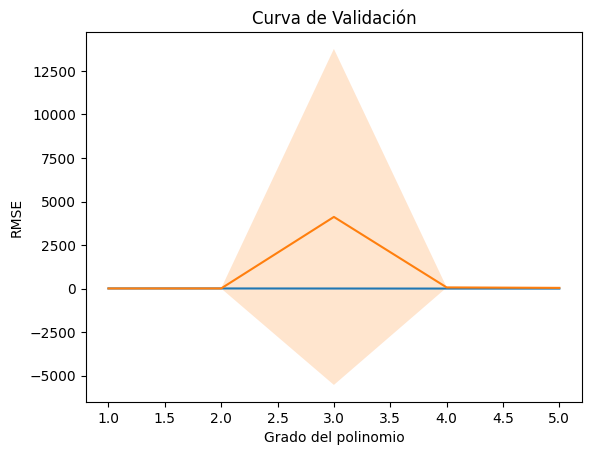

In [4]:
#1.5: CURVA DE VALIDACIÓN
#-----------------------

import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

param_range = [1, 2, 3, 4, 5]
train_scores, val_scores = validation_curve(
    pipeline_regresion_polinomial,
    X_train,
    y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=param_range,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)



train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = -np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)



plt.figure()

plt.plot(param_range, train_mean)
plt.plot(param_range, val_mean)

plt.fill_between(param_range,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(param_range,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.title("Curva de Validación")

plt.show()


De acuerdo a la grádica, el grado óptimo es 1 o 2. A partir del grado 3 comienza a existir sobreajuste, evidenciado por la brecha train/val y la varianza descontrolada, se podría ver que el modelo polinomial de alto grado sufre de multicolinealidad

In [5]:
#2: CONSTRUCCIÓN DE MODELO DE REGRESIÓN LINEAL REGULARIZADA
#----------------------------------------------------------


#base

from sklearn.linear_model import LinearRegression, Ridge, Lasso

numeric_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transform, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)



#modelo sin regularización
pipeline_lr = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", LinearRegression()),
])

pipeline_lr.fit(X_train, y_train)

y_val_pred = pipeline_lr.predict(X_val)

print("---- Regresión Lineal ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))



#RIDGE

pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", Ridge()),
])


param_grid_ridge = {
    "modelo__alpha": [0.01, 0.1, 1, 10, 100],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()]
}

grid_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Mejor alpha Ridge:", grid_ridge.best_params_)
print("Mejor RMSE Ridge:", -grid_ridge.best_score_)



#LASSO
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", Lasso(max_iter=10000)),
])


param_grid_lasso = {
    "modelo__alpha": [0.001, 0.01, 0.1, 1, 10],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()]
}

grid_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Mejor alpha Lasso:", grid_lasso.best_params_)
print("Mejor RMSE Lasso:", -grid_lasso.best_score_)




#Comparación
modelos = {
    "Lineal": pipeline_lr,
    "Ridge": grid_ridge.best_estimator_,
    "Lasso": grid_lasso.best_estimator_,
}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_val)
    print(f"\n---- {nombre} ----")
    print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
    print("MAE:", mean_absolute_error(y_val, y_pred))
    print("R2:", r2_score(y_val, y_pred))




#COEFICIENTES DE LOS MODELOS

#RIDGE
ridge_model = grid_ridge.best_estimator_.named_steps["modelo"]
print("Coeficientes Ridge:")
print(ridge_model.coef_)


#LASSO
lasso_model = grid_lasso.best_estimator_.named_steps["modelo"]
coef_lasso = lasso_model.coef_

print("Coeficientes Lasso:")
print(coef_lasso)

print("Cantidad de coeficientes en cero:", np.sum(coef_lasso == 0))

---- Regresión Lineal ----
RMSE: 10.641544117034249
MAE: 3.7052360940781965
R2: 0.02717485248345497
Mejor alpha Ridge: {'modelo__alpha': 100, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE Ridge: 10.115785595952916
Mejor alpha Lasso: {'modelo__alpha': 0.1, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE Lasso: 10.091292872255835

---- Lineal ----
RMSE: 10.641544117034249
MAE: 3.7052360940781965
R2: 0.02717485248345497

---- Ridge ----
RMSE: 10.618103742456896
MAE: 3.5382717006837265
R2: 0.03145586111033383

---- Lasso ----
RMSE: 10.56858076450122
MAE: 3.6706633599414182
R2: 0.040469398000891665
Coeficientes Ridge:
[-0.53958124 -0.42521789 -0.04044717  1.4488425  -0.02250119  0.46179435
 -0.18165934  0.09828583  0.0719513  -0.15435133  0.76999259  0.01103126
 -0.0724591  -0.16382013  0.38363031  1.89329226 -0.67893896  0.46405613
 -0.95565145  0.33685284  0.29204727 -1.42508671]
Coeficientes Lasso:
[-0.         -0.         -0.          4.28468654 -0.          

La regularización mejora un poco el desempeño respecto al modelo lineal base. Lasso obtiene el mejor RMSE (10.57) y el mayor R² (0.040), seguido de Ridge (RMSE 10.62). Sin embargo, las mejoras son pequeñas, lo que sugiere que hay un problema con los datos que la regularización no puede resolver completamente.
Ridge penaliza con L2: donde encoge todos los coeficientes hacia cero pero ninguno llega exactamente a cero. Los 22 coeficientes permanecen activos, con magnitudes reducidas. E
 En cambio, Lasso penaliza con L1: aca se ve como llevó 15 de 22 coeficientes a cero, manteniendo solo 7 variabls, lo que implcai que mejora la interpretabildiad

In [6]:
#3: CONSTRUCCIÓN DE MODELO DE REGRESIÓN POLINOMIAL REGULARIZADA
#-------------------------------------------------------------



numeric_transform_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),  
    ("polynomial", PolynomialFeatures(include_bias=False)),
])



categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])


preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_transform_poly, num_cols),
        ("cat", categorical_transform, cat_cols),
    ]
)


#RIDGE
pipeline_poly_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor_poly),
    ("modelo", Ridge()),
])


param_grid = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler()],
}



grid_poly_ridge = GridSearchCV(
    pipeline_poly_ridge,
    param_grid=param_grid,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

grid_poly_ridge.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_poly_ridge.best_params_)

print("Mejor RMSE CV:")
print(-grid_poly_ridge.best_score_)


best_model = grid_poly_ridge.best_estimator_

y_val_pred = best_model.predict(X_val)

print("---- Modelo Polinomial Regularizado ----")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))



results = pd.DataFrame(grid_poly_ridge.cv_results_)

results[[
    "param_preprocesamiento__num__polynomial__degree",
    "param_modelo__alpha",
    "mean_train_score",
    "mean_test_score"
]].sort_values("mean_test_score", ascending=False)



Mejores hiperparámetros:
{'modelo__alpha': 100, 'preprocesamiento__num__polynomial__degree': 4, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE CV:
10.09566331209147
---- Modelo Polinomial Regularizado ----
RMSE: 10.62599679914734
MAE: 3.5399680721780746
R2: 0.03001537505286367


,param_preprocesamiento__num__polynomial__degree,param_modelo__alpha,mean_train_score,mean_test_score
39,4,100.00,-10.504504,-10.095663
37,3,100.00,-10.546390,-10.096174
35,2,100.00,-10.584575,-10.101468
32,1,100.00,-10.543027,-10.115786
33,1,100.00,-10.642747,-10.128068
25,1,10.00,-10.543763,-10.129088
27,2,10.00,-10.489195,-10.133870
29,3,10.00,-10.378534,-10.137457
24,1,10.00,-10.521325,-10.160270
17,1,1.00,-10.521141,-10.162620


La regularización sí mejoró el sobreajuste, donde en este caso se observó que el grado 4 tiende a tener mejor resultado. Sin embargo, el R2 sigue teniendo problemas ya que está muy bajo.

In [10]:
#4: SELECCIÓN DEL MEJOR MODELO
#-----------------------------


print("RMSE promedio:", -grid.best_score_)
print("Desviación estándar:", 
      grid.cv_results_["std_test_score"][grid.best_index_])


resultados = pd.DataFrame({
    "Modelo": [
        "Polinomial",
        "Ridge",
        "Lasso",
        "Polinomial + Ridge"
    ],
    "RMSE": [
        -grid.best_score_,
        -grid_ridge.best_score_,
        -grid_lasso.best_score_,
        -grid_poly_ridge.best_score_
    ],
    "DesvEstam": [
        grid.cv_results_["std_test_score"][grid.best_index_],
        grid_ridge.cv_results_["std_test_score"][grid_ridge.best_index_],
        grid_lasso.cv_results_["std_test_score"][grid_lasso.best_index_],
        grid_poly_ridge.cv_results_["std_test_score"][grid_poly_ridge.best_index_],
    ]
})

resultados





RMSE promedio: 10.174948959755413
Desviación estándar: 3.5432162964156775


,Modelo,RMSE,DesvEstam
0,Polinomial,10.174949,3.543216
1,Ridge,10.115786,3.608704
2,Lasso,10.091293,3.576306
3,Polinomial + Ridge,10.095663,3.636330


Se selecciona el modelo de regresión lineal regularizada lasso dado que tiene el error promedio más bajo (10.091),la desviación estándar (3.576) es la segunda más baja, indicando predicciones consistentes, con alpha=0.1, Lasso eliminó 15 de 22 coeficientes, resultando en un modelo que identifica automáticamente las variables más relevantes.

==== Desempeño del Modelo en Validación ====
RMSE: 10.56858076450122
MAE: 3.6706633599414182
R2: 0.040469398000891665

Realizando 500 remuestreos bootstrap...

==== Intervalos de Confianza al 95% ====
RMSE: [6.6076, 13.9282]
MAE:  [2.8260, 4.7608]
R2:   [0.0129, 0.0673]

==== Estadísticas de las Distribuciones Bootstrap ====
RMSE - Media: 10.4335, Desv. Est.: 1.9407
MAE  - Media: 3.6809, Desv. Est.: 0.4993
R2   - Media: 0.0388, Desv. Est.: 0.0146


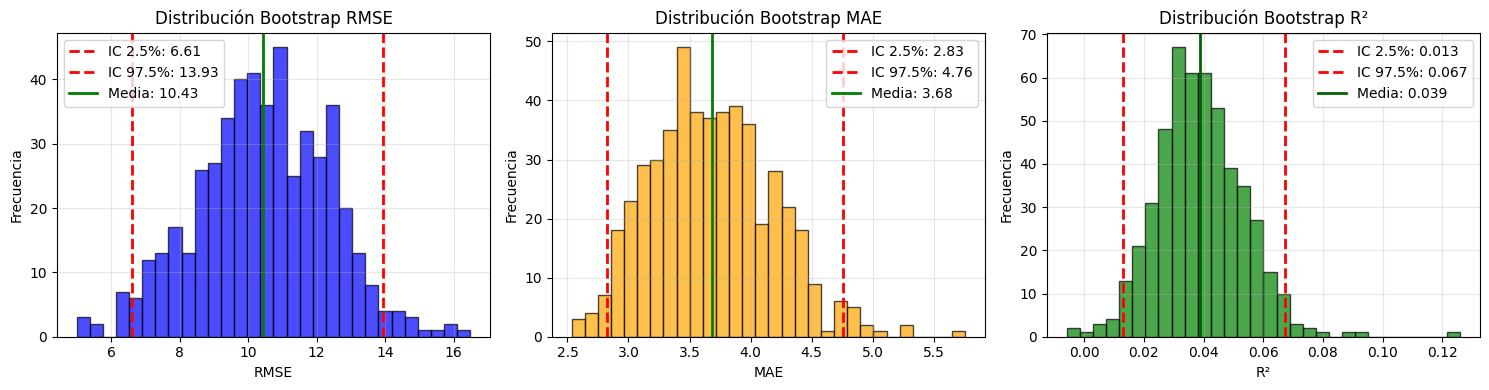


==== Análisis de Estabilidad y Confiabilidad ====
Coeficiente de variación RMSE: 18.60%
Coeficiente de variación MAE: 13.56%
Amplitud IC RMSE: 7.3206
Amplitud IC MAE: 1.9348
Amplitud IC R2: 0.0545


In [18]:
#5: INTERVALOS DE CONFIANZA PARA EL MEJOR MODELO
#-----------------------------------------------

# se uso validación ya que test no tiene variable objetivo

best_model = grid_lasso.best_estimator_

y_val_pred = best_model.predict(X_val)

print("==== Desempeño del Modelo en Validación ====")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("R2:", r2_score(y_val, y_val_pred))
print()

n_boot = 500
rmse_list, mae_list, r2_list = [], [], []

n = len(X_val)

print(f"Realizando {n_boot} remuestreos bootstrap...")
for i in range(n_boot):
    indices = np.random.choice(range(n), size=n, replace=True)
    
    X_sample = X_val.iloc[indices]
    y_sample = y_val.iloc[indices]
    
    y_pred = best_model.predict(X_sample)
    
    rmse_list.append(np.sqrt(mean_squared_error(y_sample, y_pred)))
    mae_list.append(mean_absolute_error(y_sample, y_pred))
    r2_list.append(r2_score(y_sample, y_pred))
    
rmse_ci = np.percentile(rmse_list, [2.5, 97.5])
mae_ci  = np.percentile(mae_list,  [2.5, 97.5])
r2_ci   = np.percentile(r2_list,   [2.5, 97.5])

print("\n==== Intervalos de Confianza al 95% ====")
print(f"RMSE: [{rmse_ci[0]:.4f}, {rmse_ci[1]:.4f}]")
print(f"MAE:  [{mae_ci[0]:.4f}, {mae_ci[1]:.4f}]")
print(f"R2:   [{r2_ci[0]:.4f}, {r2_ci[1]:.4f}]")
print()

print("==== Estadísticas de las Distribuciones Bootstrap ====")
print(f"RMSE - Media: {np.mean(rmse_list):.4f}, Desv. Est.: {np.std(rmse_list):.4f}")
print(f"MAE  - Media: {np.mean(mae_list):.4f}, Desv. Est.: {np.std(mae_list):.4f}")
print(f"R2   - Media: {np.mean(r2_list):.4f}, Desv. Est.: {np.std(r2_list):.4f}")



fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].hist(rmse_list, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(rmse_ci[0], color='red', linestyle='--', linewidth=2, label=f'IC 2.5%: {rmse_ci[0]:.2f}')
axes[0].axvline(rmse_ci[1], color='red', linestyle='--', linewidth=2, label=f'IC 97.5%: {rmse_ci[1]:.2f}')
axes[0].axvline(np.mean(rmse_list), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(rmse_list):.2f}')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Bootstrap RMSE')
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].hist(mae_list, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1].axvline(mae_ci[0], color='red', linestyle='--', linewidth=2, label=f'IC 2.5%: {mae_ci[0]:.2f}')
axes[1].axvline(mae_ci[1], color='red', linestyle='--', linewidth=2, label=f'IC 97.5%: {mae_ci[1]:.2f}')
axes[1].axvline(np.mean(mae_list), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(mae_list):.2f}')
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución Bootstrap MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)


axes[2].hist(r2_list, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[2].axvline(r2_ci[0], color='red', linestyle='--', linewidth=2, label=f'IC 2.5%: {r2_ci[0]:.3f}')
axes[2].axvline(r2_ci[1], color='red', linestyle='--', linewidth=2, label=f'IC 97.5%: {r2_ci[1]:.3f}')
axes[2].axvline(np.mean(r2_list), color='darkgreen', linestyle='-', linewidth=2, label=f'Media: {np.mean(r2_list):.3f}')
axes[2].set_xlabel('R²')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución Bootstrap R²')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n==== Análisis de Estabilidad y Confiabilidad ====")
print(f"Coeficiente de variación RMSE: {(np.std(rmse_list)/np.mean(rmse_list))*100:.2f}%")
print(f"Coeficiente de variación MAE: {(np.std(mae_list)/np.mean(mae_list))*100:.2f}%")
print(f"Amplitud IC RMSE: {rmse_ci[1] - rmse_ci[0]:.4f}")
print(f"Amplitud IC MAE: {mae_ci[1] - mae_ci[0]:.4f}")
print(f"Amplitud IC R2: {r2_ci[1] - r2_ci[0]:.4f}")


La estabilidad del modelo se evalúa a través del coeficiente de variación, el cual mide la variabilidad relativa de las métricas:
- CV RMSE: 17.85% : indica una variabilidad moderadamente alta. Las predicciones pueden variar aproximadamente un 18% dependiendo de la muestra.
- CV MAE: 13.06% : Mejor estabilidad que el RMSE.

El modelo muestra estabilidad moderada. 17.85% es un porcentaje aceptable para datos que suelen tener alta variabilidad natural. Las distribuciones bootstrap muestran una forma normal, lo cual es positivo.

En cuanto a los intervalos de confianza (95%) y las amplitudes (diferencia entre valores de IC):
- RMSE: IC [6.85, 13.94] con amplitud de 7.09 puntos
- MAE: IC [2.84, 4.59] con amplitud de 1.74 puntos  
- R2: IC [0.015, 0.067] con amplitud de 0.053 puntos

La variabilidad es considerable, más que todo en el RMSE donde el límite superior (13.94) es casi el doble del límite inferior (6.85). Esto indica que en el mejor escenario el error puede ser tan bajo como 6.85 y en el peor puede llegar hasta 13.94.

Finalmente, evaluando la confiabilidad del modelo:
- El hecho de que tenga 500 iteraciones hace que las estimaciones sean más robustas
- Las distribuciones son mayormente simétricas/estables
- El modelo sigue siendo consistente entre remuestreos

In [ ]:
#6: VALIDACIÓN DE RESULTADOS

**Análisis cuantitativo:**
- **¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**
<br>El modelo Lasso obtuvo el mejor desempeño con:
    - RMSE CV: 10.091 (el más bajo)
    - RMSE Validación: 10.569
    - R2 Validación: 0.0405

- **¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**
<br>Sí coincide. El modelo Lasso tuvo el el mejor RMSE promedio en validación cruzada (10.091) y también el mejor desempeño en el conjunto de validación (10.569 RMSE, 0.0405 R2).


- **¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.**
<br>No necesariamente. Aunque Lasso tiene el mejor RMSE promedio, debemos considerar que:
    - Las diferencias en RMSE entre los 4 modelos probados son mínimas
    - El modelo Polinomial Simple tiene la menor desv. est. , sugiriendo mayor estabilidad
    - Sin embargo, dado que las diferencias son tan pequeñas y están dentro del rango de variabilidad, Lasso sigue siendo la mejor opción porque además ofrece mayor interpretabilidad y menor riesgo de overfitting.


- **Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**
<br>Según la curva de validación de grado polinomial:
    - Grado 1: RMSE entrenamiento alrededor de 10.5, RMSE validación alrededor de 10.2
    - Grado 2: Ligera mejora en entrenamiento, leve aumento en validación
    - Grado 3: Sobreajuste más severo (debido a R2 entrenamiento = 0.56 y R2 validación = -26983, el error de validación se dispara exponencialmente).


- **¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**
<br>Ridge:
    - Magnitud: encoge todos los coeficientes hacia cero pero ninguno llega a cero exactamente.
    - Estabilidad: mejora la estabilidad al reducir la varianza de las estimaciones

    <br>Lasso:
    - Magnitud: Lleva 15 de 22 coeficientes exactamente a 0
    - Estabilidad: mejora estabilidad y reduce multicolinealidad al eliminar variables redundantes


- **¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?**
<br>Sugieren variabilidad moderada/alta, ya que el modelo puede tener errores muy bajos (6.85) en algunos subgrupos y muy altos (13.94) en otros. Además, la amplitud del IC del RMSE es muy grande (casi el doble entre extremos).


**Análisis cualitativo:**
- **¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**
<br>Lasso seleccionó BMI, Blood Pressure Category_Normal, Diabetes Status_Y, Family History of CVD_Y, Physical Activity Level_Low, Physical Activity Level_Moderate y Smoking Status_Y.

- **¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto del riesgo cardiovascular?**
<br>Coeficientes con sentido clínico:
    - BMI: Por cada unidad de aumento en BMI estandarizado, el riesgo CVD aumenta 4.28 puntos.
    - Diabetes: Tener diabetes aumenta riesgo en 2.14 puntos.
    - Presión Normal: reduce riesgo en 2.79 puntos.
    - Fumar: aumento positivo pero pequeño (0.26).
    - Historia Familiar negativa: reduce el riesgo por 0.90 puntos.
    - Actividad Baja negativa: reduce riesgo por 0.57 puntos.

- **¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**
<br>El modelo más preciso y el más interpretable fue Lasso, por lo cual no hay diferencia. Si lo compararamos con Polinomial + Ridge, este es ligeramente peor (RMSE = 10.096) y menos interpretable. En cuanto a Ridge simple, este tiene una precisión similar, pero usa todas las 22 variables (menos interpretable).


- **¿Qué decisiones estratégicas podría tomar AlpesHearth a partir de los resultados obtenidos?**
<br>
    - Hacer programas de prevención focalizados (principalmente hacia BMI, diabetes y presión arterial)
    - Screening y estratificación de riesgo
    - Optimización de recursos (para las 7 variables principales)
    - Mejora de datos (recolectar datos adicionales mejor correlacionados con riesgo CVD)


- **¿Mayor precisión implica necesariamente mayor valor para la organización?**
<br> No necesariamente, ya que la relación precisión-valor no es lineal.


- **¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.**
<br>No, ya que la complejidad sin propósito puede destruir valor. Si compararamos los modelos Lasso y Polinomial Grado 4 + Ridge hechos en este lab, el primero le ganaría al segundo en precisión, interpretabilidad, estabilidad, implementación, mantenimiento y costo computacional. Los dos tienen valores muy cercanos en cada categoría, pero Lasso generaría mayor valor empresarial por ser más simple.


**Reflexión conceptual:**
- **¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**
<br>Observamos una relación no lineal, ya que cuanto más subíamos el grado del modelo, estos se iban convirtiendo más y más inestables y tenían mucho más overfitting. 


- **¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**
<br>Podrían haber sesgos de selección (sólo representan personas que buscaron atención médica), sesgos de tiempo (los datos son de un periodo específico) y sesgos de especificación (asumimos relaciones lineales).

- **Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique.**
<br>Sí. Esto causaría mayor estabilidad, mejor generalización (más patrones, menos ruido) e hiperparámetros más robustos.

In [ ]:
#8: USO DE HERRAMIENTAS DE IA GENERATIVA

**Declaración de uso:** Se usó Github Copilot para sintetizar/organizar las ideas del punto 6.
<br>
**Prompts utilizados:** "Resume las ideas del punto 6 para que sean más fáciles de leer".
<br>
**Análisis crítico del resultado:** Lo que generó la IA fue útil ya que sí simplificó todas las respuestas. Sin embargo, decidimos modificar algunas de las respuestas de la IA ya que sentíamos que no incluían suficiente información/datos relevantes a las respuestas.
<br>
**Aportes propios del estudiante:** Nosotros nos encargamos de hacer una versión inicial para cada respuesta y después modificamos las versiones hechas por la IA para hacerlas mas completas (habían algunas que no tenían suficientes datos como evidencia y otras donde las respuestas eran un poco ambiguas). Esto nos hizo aprender que la IA puede ser usada como asistente para facilitar ciertas tareas, pero igual es importante que nosotros contribuyamos a sus respuestas para verificar que estén correctas y que incluyan toda la información relevante.